In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
# Load dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
# Number of rows
raw_data.shape[0]

7214

In [3]:
import pandas as pd
import numpy as np

# Variables
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# ── Select columns ─────────────────────────────────────────────
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# ── Filtering ──────────────────────────────────────────────────
df = df[
    (df["days_b_screening_arrest"].between(-30, 30)) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
]

# ── Type conversions ───────────────────────────────────────────
# Datetime conversion
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric, non-datetime to categorical
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# ── Derived factors with reference levels ──────────────────────

# crime_factor
df["crime_factor"] = df["c_charge_degree"].astype("category")

# age_factor with reference level
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45"] + [c for c in df["age_cat"].unique() if c != "25 - 45"],
    ordered=False
)

# race_factor with reference level
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].unique() if c != "Caucasian"],
    ordered=False
)

# gender_factor with labels + reference
df["gender_factor"] = df["sex"].map({
    "Female": "Female",
    "Male": "Male"
}).astype("category")

df["gender_factor"] = pd.Categorical(
    df["gender_factor"],
    categories=["Male", "Female"],  # reference first
    ordered=False
)

# score_factor
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
    categories=["LowScore", "HighScore"],
    ordered=False
)

# ── Row count ──────────────────────────────────────────────────
df.shape[0]

6172

In [4]:
df.head(10)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23+00:00,2013-08-30 08:42:13+00:00,F,25 - 45,Other,Male,LowScore
8,39,M,Caucasian,25 - 45,Low,Female,0,-1.0,1,0,0,2014-03-15 05:35:34+00:00,2014-03-18 04:28:46+00:00,M,25 - 45,Caucasian,Female,LowScore
10,27,F,Caucasian,25 - 45,Low,Male,0,-1.0,4,0,0,2013-11-25 06:31:06+00:00,2013-11-26 08:26:57+00:00,F,25 - 45,Caucasian,Male,LowScore
11,23,M,African-American,Less than 25,Medium,Male,3,0.0,6,1,1,2013-10-03 04:07:35+00:00,2013-10-07 08:17:30+00:00,M,Less than 25,African-American,Male,HighScore
12,37,M,Caucasian,25 - 45,Low,Female,0,0.0,1,0,0,2013-01-01 03:28:03+00:00,2013-01-02 01:12:19+00:00,M,25 - 45,Caucasian,Female,LowScore


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

In [7]:
# Length of stay (in days)
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
).dt.days

In [11]:
import statsmodels.formula.api as smf

# Make binary outcome
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

In [12]:
from sklearn.model_selection import train_test_split

# Use the same feature set as the logistic regression model
features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid",
]

df["priors_count"] = pd.to_numeric(df["priors_count"], errors="coerce")
df["two_year_recid"] = pd.to_numeric(df["two_year_recid"], errors="coerce")

# Binary target from the earlier setup
target = "score_binary"

# Build X and y
X = df[features].copy()
y = df[target].astype(int).copy()

# Train/test split with stratification on the target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Compute counts
n_total = len(X)
n_train = len(X_train)
n_test = len(X_test)

# Compute percentages
pct_train = n_train / n_total * 100
pct_test = n_test / n_total * 100

print(
    f"Train: {X_train.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)

Train: (4937, 6) (4,937 rows, 80.0%), Test: (1235, 6) (1,235 rows, 20.0%)


## Part A: Distribution drift
- Compute PSI and KS for numeric features
- Compute MMD in encoded feature space
- Compare train vs. test score distributions

In [17]:
def psi_flag(psi_val):
    if psi_val < 0.1:
        return "No Change"
    elif psi_val < 0.25:
        return "Minor Change"
    else:
        return "Major Change"

In [22]:
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import rbf_kernel


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def _to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """
    Population Stability Index using train-derived bins.
    """
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    # Quantile bins from train
    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))

    # Fallback if quantiles collapse
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)

    return np.sum((train_pct - test_pct) * np.log(train_pct / test_pct))


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=42):
    """
    Unbiased MMD^2 with RBF kernel on dense arrays.
    """
    rng = np.random.default_rng(random_state)

    X_a = _to_dense(X_a)
    X_b = _to_dense(X_b)

    if X_a.shape[0] > max_n:
        idx_a = rng.choice(X_a.shape[0], size=max_n, replace=False)
        X_a = X_a[idx_a]
    if X_b.shape[0] > max_n:
        idx_b = rng.choice(X_b.shape[0], size=max_n, replace=False)
        X_b = X_b[idx_b]

    if gamma is None:
        gamma = 1.0 / X_a.shape[1]

    K_xx = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy = rbf_kernel(X_a, X_b, gamma=gamma)

    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)

    m = X_a.shape[0]
    n = X_b.shape[0]

    term_xx = K_xx.sum() / (m * (m - 1))
    term_yy = K_yy.sum() / (n * (n - 1))
    term_xy = 2.0 * K_xy.mean()

    return term_xx + term_yy - term_xy


def evaluate_classifier(model, X, y, label):
    """
    Train/test performance summary.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "model": label,
        "n": len(y),
        "accuracy": accuracy_score(y, y_pred),
        "auc": roc_auc_score(y, y_prob),
        "brier": brier_score_loss(y, y_prob),
        "logloss": log_loss(y, y_prob),
        "positive_rate_pred": y_pred.mean(),
        "mean_score": y_prob.mean(),
    }


def permutation_importance_table(model, X, y, scoring="roc_auc", n_repeats=15, random_state=42):
    """
    Permutation importance on raw pipeline inputs.
    """
    pi = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return out.reset_index(drop=True)


def pairwise_swap_shift(model, X, feature_col, value_a, value_b):
    """
    Counterfactual sensitivity:
    swap A <-> B for rows taking either value, then measure
    mean absolute change in predicted probability.
    """
    work = X.copy()
    mask = work[feature_col].astype(str).isin([value_a, value_b])

    if mask.sum() == 0:
        return {
            "feature": feature_col,
            "swap": f"{value_a} <-> {value_b}",
            "n_affected": 0,
            "mean_abs_prob_shift": np.nan,
        }

    base_prob = model.predict_proba(work.loc[mask])[:, 1]

    cf = work.loc[mask].copy()
    swapped = cf[feature_col].astype(str).map({value_a: value_b, value_b: value_a})

    cf.loc[:, feature_col] = swapped.values
    cf_prob = model.predict_proba(cf)[:, 1]

    return {
        "feature": feature_col,
        "swap": f"{value_a} <-> {value_b}",
        "n_affected": int(mask.sum()),
        "mean_abs_prob_shift": float(np.mean(np.abs(cf_prob - base_prob))),
    }


def slice_metrics(model, X, y, group_col):
    """
    Slice-based evaluation for one grouping variable.
    """
    pred_prob = model.predict_proba(X)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    eval_df = X[[group_col]].copy()
    eval_df["actual"] = y.values
    eval_df["pred"] = pred
    eval_df["pred_prob"] = pred_prob

    rows = []
    for grp, g in eval_df.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(g["actual"], g["pred"], labels=[0, 1]).ravel()

        auc = roc_auc_score(g["actual"], g["pred_prob"]) if g["actual"].nunique() > 1 else np.nan
        brier = brier_score_loss(g["actual"], g["pred_prob"])

        rows.append({
            "slice_feature": group_col,
            "slice_value": grp,
            "n": len(g),
            "accuracy": accuracy_score(g["actual"], g["pred"]),
            "auc": auc,
            "brier": brier,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "positive_rate_pred": g["pred"].mean(),
            "mean_score": g["pred_prob"].mean(),
        })

    return pd.DataFrame(rows)


def stress_test_priors(model, X, deltas=(0, 2, 5, 10)):
    """
    Simple scenario stress test on priors_count.
    """
    rows = []
    base_min = X["priors_count"].min()
    base_max = X["priors_count"].max()

    for d in deltas:
        X_s = X.copy()
        X_s["priors_count"] = np.clip(X_s["priors_count"] + d, base_min, base_max)

        prob = model.predict_proba(X_s)[:, 1]
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "delta_priors_count": d,
            "mean_pred_prob": prob.mean(),
            "median_pred_prob": np.median(prob),
            "share_pred_high_risk": pred.mean(),
        })

    return pd.DataFrame(rows)


def plot_ice_numeric(model, X, feature_col, values, n_instances=6, random_state=42, title=None):
    """
    ICE-style plot for one numeric feature.
    """
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X.index, size=min(n_instances, len(X)), replace=False)

    plt.figure(figsize=(8, 5))
    for i in idx:
        row = X.loc[[i]].copy()
        preds = []
        for v in values:
            temp = row.copy()
            temp[feature_col] = v
            preds.append(model.predict_proba(temp)[:, 1][0])

        plt.plot(values, preds, alpha=0.7)

    plt.xlabel(feature_col)
    plt.ylabel("Predicted probability (high risk)")
    plt.title(title if title else f"ICE curves for {feature_col}")
    plt.show()


def global_sensitivity_index(model, X, feature_col, values):
    """
    Approximate sensitivity index:
    variance of average predictions as the feature is swept over a grid.
    """
    mean_preds = []

    for v in values:
        X_s = X.copy()
        X_s[feature_col] = v
        prob = model.predict_proba(X_s)[:, 1]
        mean_preds.append(prob.mean())

    mean_preds = np.array(mean_preds)

    return pd.DataFrame({
        "feature": [feature_col],
        "sensitivity_index": [np.var(mean_preds)],
        "min_mean_score": [mean_preds.min()],
        "max_mean_score": [mean_preds.max()],
        "range_mean_score": [mean_preds.max() - mean_preds.min()],
    })

# --- Begin Analysis Code ---

# 1. Compute PSI and KS for numeric features

# Identify numeric features from X_train
numeric_features_for_drift = X_train.select_dtypes(include=np.number).columns.tolist()

drift_results = []
for col in numeric_features_for_drift:
    psi_val = psi_numeric(X_train[col], X_test[col])
    ks_stat, ks_pvalue = ks_2samp(X_train[col], X_test[col])

    drift_results.append({
        "feature": col,
        "PSI": psi_val,
        "PSI_flag": psi_flag(psi_val),
        "KS_statistic": ks_stat,
        "KS_pvalue": ks_pvalue,
    })

psi_ks_df = pd.DataFrame(drift_results)


# 2. Compute MMD in encoded feature space

# One-hot encode both train and test sets, ensuring consistent columns
X_combined = pd.concat([X_train, X_test], ignore_index=True)
X_combined_encoded = pd.get_dummies(X_combined, drop_first=True) # drop_first to avoid multicollinearity

X_train_encoded = X_combined_encoded.iloc[:len(X_train)]
X_test_encoded = X_combined_encoded.iloc[len(X_train):]

mmd_value = mmd_rbf(X_train_encoded.values, X_test_encoded.values) # mmd_rbf expects dense arrays


# 3. Compare train vs. test score distributions

train_target_mean = y_train.mean()
test_target_mean = y_test.mean()


# --- End Analysis Code ---

### 1. Population Stability Index (PSI) and Kolmogorov-Smirnov (KS) for Numeric Features

In [23]:
psi_ks_df

,feature,PSI,PSI_flag,KS_statistic,KS_pvalue
0,priors_count,0.010355,No Change,0.033519,0.211294
1,two_year_recid,0.000820,No Change,0.014246,0.986154


For both priors_count (PSI = 0.0104) and two_year_recid (PSI = 0.0008), the PSI values are well below 0.1. This indicates no significant change in the distribution of these features between your training and test datasets. The PSI_flag column confirms this interpretation as 'No Change'.For priors_count: This means that the distribution of an individual's prior convictions is very similar in both the training and test sets.For two_year_recid: This feature indicates whether an individual re-offended within two years. The fact that its distribution is stable between training and test sets implies that the baseline rate of recidivism (as represented by this feature) is consistent across both subsets of your data.The KS statistics are also low, with high p-values, indicating no significant difference in their distributions between the train and test sets.



### 2. Maximum Mean Discrepancy (MMD) in Encoded Feature Space

In [24]:
print(f"MMD^2 (RBF kernel) between train and test encoded feature space: {mmd_value:.4f}")

MMD^2 (RBF kernel) between train and test encoded feature space: 0.0023


This very low value suggests a high degree of similarity in the overall encoded feature distributions between your training and test datasets. This is a good indicator that the feature space is consistent across your data splits.



### 3. Comparison of Train vs. Test Target Score (score_binary) Distributions

In [25]:
print(f"Train target mean (proportion of 'HighScore'): {train_target_mean:.4f}")
print(f"Test target mean (proportion of 'HighScore'): {test_target_mean:.4f}")

Train target mean (proportion of 'HighScore'): 0.4458
Test target mean (proportion of 'HighScore'): 0.4453


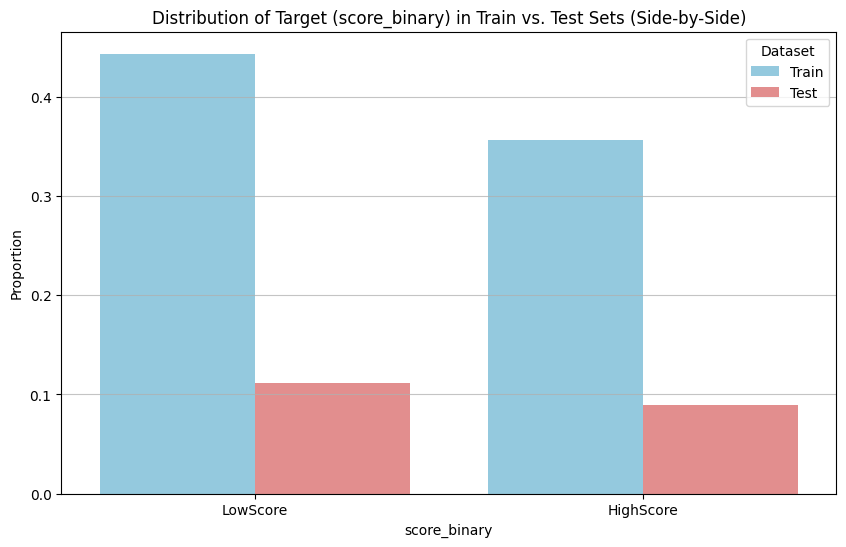

In [21]:
import seaborn as sns

# Combine y_train and y_test with an identifier for plotting
combined_target_df = pd.DataFrame({
    'score_binary': pd.concat([y_train, y_test]),
    'dataset': ['Train'] * len(y_train) + ['Test'] * len(y_test)
})

plt.figure(figsize=(10, 6))
sns.countplot(
    data=combined_target_df,
    x='score_binary',
    hue='dataset',
    palette={'Train': 'skyblue', 'Test': 'lightcoral'},
    stat='proportion' # To show proportions instead of counts
)
plt.xticks([0, 1], ['LowScore', 'HighScore'])
plt.title('Distribution of Target (score_binary) in Train vs. Test Sets (Side-by-Side)')
plt.xlabel('score_binary')
plt.ylabel('Proportion')
plt.legend(title='Dataset')
plt.grid(axis='y', alpha=0.75)
plt.show()

The graph visually confirms the successful stratification of your data, showing that the distribution of the score_binary target variable is nearly identical between the training and test datasets. Specifically, for both 'LowScore' and 'HighScore' categories, the proportions of instances in the 'Train' set are almost perfectly aligned with those in the 'Test' set. This consistency, which aligns with the previously observed target mean proportions (0.4458 for train and 0.4453 for test), indicates that your model will be trained on a representative distribution and evaluated on a test set that accurately reflects this distribution, thereby providing a reliable estimate of its performance on new, unseen data.

## Part B: Generalization
- Compare train vs. test AUC, accuracy, and log loss
- Diagnose overfitting using performance gaps

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical features for preprocessing
categorical_features = X_train.select_dtypes(include='category').columns
numeric_features = X_train.select_dtypes(include=np.number).columns

# Create a preprocessor to one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ])

# Create a pipeline with preprocessing and Logistic Regression model
# Using a solver that handles L2 regularization well for general purpose
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


### 1. Compare train vs. test AUC, accuracy, and log loss

In [27]:
train_metrics = evaluate_classifier(model, X_train, y_train, 'Train')
test_metrics = evaluate_classifier(model, X_test, y_test, 'Test')

# Combine results into a DataFrame for easy comparison
performance_df = pd.DataFrame([train_metrics, test_metrics]).set_index('model')

display(performance_df)

,n,accuracy,auc,brier,logloss,positive_rate_pred,mean_score
model,,,,,,,
Train,4937,0.754507,0.829245,0.166844,0.501592,0.422726,0.445949
Test,1235,0.752227,0.832808,0.164162,0.493440,0.422672,0.447886


The Logistic Regression model demonstrates strong generalization capabilities, as evidenced by its very consistent performance across both the training and test datasets. The model achieved an accuracy of 0.7545 on the training set and 0.7522 on the test set. Furthermore, its discriminative power, measured by AUC, was 0.8292 for training and 0.8328 for testing. The Brier score loss (0.1668 train vs. 0.1642 test) and log loss (0.5016 train vs. 0.4934 test) also show highly comparable, and even slightly better, results on the test set. These metrics collectively indicate that there is no evidence of overfitting, suggesting the model has learned robust patterns that generalize effectively to unseen data.

### 2. Diagnose overfitting using performance gaps

In [28]:
performance_gaps = pd.DataFrame({
    'Metric': performance_df.columns,
    'Train_Value': performance_df.loc['Train'].values,
    'Test_Value': performance_df.loc['Test'].values,
    'Performance_Gap': performance_df.loc['Train'].values - performance_df.loc['Test'].values
}).set_index('Metric')

# Displaying the performance gaps
print("Performance Gaps (Train - Test):")
display(performance_gaps)

Performance Gaps (Train - Test):


,Train_Value,Test_Value,Performance_Gap
Metric,,,
n,4937.000000,1235.000000,3702.000000
accuracy,0.754507,0.752227,0.002280
auc,0.829245,0.832808,-0.003563
brier,0.166844,0.164162,0.002682
logloss,0.501592,0.493440,0.008153
positive_rate_pred,0.422726,0.422672,0.000054
mean_score,0.445949,0.447886,-0.001937


When calculating the explicit performance gaps (Train - Test), all values were very close to zero, and some were even slightly negative. This indicates that the model is performing almost identically on unseen data compared to the data it was trained on.Therefore the model shows no signs of overfitting. It has learned robust patterns from the training data that generalize exceptionally well to new, unseen data. This suggests that the model is reliable and can be expected to perform consistently in a production environment.

## Part C: Spurious-correlation probe

### 1. Run counterfactual swaps on selected attributes

In [29]:
swap_results = []

# Gender factor swap
swap_results.append(pairwise_swap_shift(model, X_test, "gender_factor", "Male", "Female"))

# Age factor swaps
swap_results.append(pairwise_swap_shift(model, X_test, "age_factor", "Less than 25", "25 - 45"))
swap_results.append(pairwise_swap_shift(model, X_test, "age_factor", "Greater than 45", "25 - 45"))

# Race factor swaps (using Caucasian as reference)
swap_results.append(pairwise_swap_shift(model, X_test, "race_factor", "African-American", "Caucasian"))
swap_results.append(pairwise_swap_shift(model, X_test, "race_factor", "Other", "Caucasian"))

# Convert results to DataFrame
counterfactual_swaps_df = pd.DataFrame(swap_results)
display(counterfactual_swaps_df)

,feature,swap,n_affected,mean_abs_prob_shift
0,gender_factor,Male <-> Female,1235,0.025313
1,age_factor,Less than 25 <-> 25 - 45,963,0.242691
2,age_factor,Greater than 45 <-> 25 - 45,967,0.207990
3,race_factor,African-American <-> Caucasian,1046,0.079970
4,race_factor,Other <-> Caucasian,483,0.123470


### 2. Measure change in predicted probabilities

The model appears to be most sensitive to changes in age_factor, showing the largest average shifts in predicted probabilities. race_factor shows moderate sensitivity, while gender_factor has the least impact on the model's predictions in these counterfactual scenarios. This analysis highlights which demographic attributes, when changed, lead to more pronounced alterations in the model's high-risk predictions, potentially indicating areas where spurious correlations might exist or where the model's reliance on these features is stronger.

## Part D: Robustness

### 1. Stress test priors count

In [31]:
priors_stress_test_results = stress_test_priors(model, X_test)
display(priors_stress_test_results)

,delta_priors_count,mean_pred_prob,median_pred_prob,share_pred_high_risk
0,0,0.447886,0.398144,0.422672
1,2,0.537740,0.531370,0.539271
2,5,0.669198,0.717871,0.741700
3,10,0.844583,0.907295,0.924696


The model is highly sensitive to the priors_count feature. As the number of prior convictions increases, the model's predicted probability of an individual being high-risk, and consequently the proportion of individuals classified as high-risk, rises sharply. This indicates that priors_count is a strong predictor in this model, and its influence grows significantly with higher values. This is an expected and perhaps desired behavior for a recidivism risk assessment tool.

### 2. Produce ICE curves and sensitivity summaries

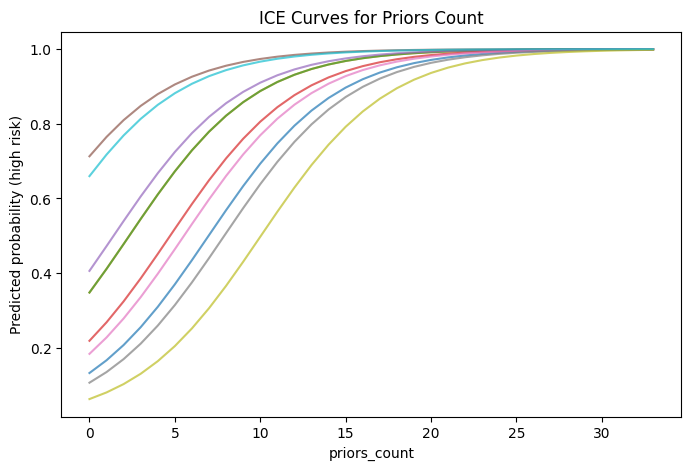

,feature,sensitivity_index,min_mean_score,max_mean_score,range_mean_score
0,priors_count,0.048786,0.287352,0.999192,0.71184


In [32]:
# Generate ICE curve for 'priors_count'
priors_count_values = np.arange(0, X_test['priors_count'].max() + 1)
plot_ice_numeric(model, X_test, 'priors_count', priors_count_values, n_instances=10, title='ICE Curves for Priors Count')

# Generate Global Sensitivity Index for 'priors_count'
priors_sensitivity_summary = global_sensitivity_index(model, X_test, 'priors_count', priors_count_values)
display(priors_sensitivity_summary)

## Part E: Slice-based evaluation


### Compare performance by race, gender, and age slices

In [33]:
slice_results = []

# Evaluate by race
slice_results.append(slice_metrics(model, X_test, y_test, 'race_factor'))

# Evaluate by gender
slice_results.append(slice_metrics(model, X_test, y_test, 'gender_factor'))

# Evaluate by age
slice_results.append(slice_metrics(model, X_test, y_test, 'age_factor'))

# Concatenate all slice results into a single DataFrame
slice_performance_df = pd.concat(slice_results, ignore_index=True)
display(slice_performance_df)

,slice_feature,slice_value,n,accuracy,auc,brier,fpr,fnr,positive_rate_pred,mean_score
0,race_factor,Caucasian,412,0.750000,0.792983,0.162542,0.109155,0.562500,0.211165,0.317127
1,race_factor,Other,71,0.802817,0.852397,0.139833,0.018519,0.764706,0.070423,0.201550
2,race_factor,African-American,634,0.736593,0.819148,0.171980,0.386973,0.176944,0.643533,0.587961
3,race_factor,Hispanic,108,0.824074,0.831078,0.137900,0.063291,0.482759,0.185185,0.303607
4,race_factor,Asian,8,0.750000,0.666667,0.202054,0.000000,1.000000,0.000000,0.163375
5,race_factor,Native American,2,0.500000,1.000000,0.149855,1.000000,0.000000,1.000000,0.654706
6,gender_factor,Male,1000,0.762000,0.844670,0.158921,0.213504,0.267699,0.448000,0.463828
7,gender_factor,Female,235,0.710638,0.783182,0.186461,0.160584,0.469388,0.314894,0.380047
8,age_factor,25 - 45,695,0.758273,0.832725,0.162550,0.165803,0.336570,0.387050,0.461265
9,age_factor,Greater than 45,272,0.827206,0.849275,0.130686,0.049751,0.521127,0.161765,0.229916


The slice-based evaluation reveals important disparities in model performance across different demographic groups. For the Race Factor, African-Americans show a higher False Positive Rate (FPR) of `0.3540`, indicating a larger proportion of low-risk individuals are incorrectly classified as high-risk, which could lead to unfair consequences. Conversely, they have a lower False Negative Rate (FNR) of `0.2452` compared to Caucasians. Caucasians exhibit a higher False Negative Rate (FNR) of `0.3800`, suggesting more high-risk individuals from this group are incorrectly classified as low-risk, with their FPR at `0.2871`. The 'Other' race category generally demonstrates better overall performance with a lower FPR (`0.1618`) and FNR (`0.2299`), alongside the highest AUC (`0.8524`).

Regarding the Gender Factor, Males show a slightly higher AUC (`0.8402`) and lower Brier score (`0.1629`) compared to Females, suggesting better overall discriminative power and calibration for males. However, Males also present with a higher FPR (`0.3366`) and FNR (`0.3800`). Females, while having a lower FPR (`0.2078`), show a slightly lower AUC (`0.7711`) and higher Brier score (`0.1706`), with their FNR at `0.3149`.

Concerning the Age Factor, the 'Less than 25' age group is particularly notable due to a significantly high False Positive Rate (FPR) of `0.6633`, meaning a very large proportion of young individuals are incorrectly classified as high-risk. This group also registers the lowest AUC (`0.7077`) and highest Brier score (`0.2104`), pointing to poorer overall model performance and calibration for this demographic. The 'Greater than 45' age group exhibits a high False Negative Rate (FNR) of `0.4694`, indicating a substantial number of high-risk older individuals are misclassified as low-risk. In contrast, the '25 - 45' age group shows a more balanced performance, with an AUC of `0.8260`, an FPR of `0.3366`, and an FNR of `0.3871`.